In [1]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
# transform = transforms.Compose(
#     [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
# )

train_data = datasets.QMNIST(
    root="./data", what="train", download=True, transform=ToTensor()
)
test_data = datasets.QMNIST(
    root="./data", what="test", download=True, transform=ToTensor()
)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Image shape: {train_data[0][0].shape}")
print(f"Label: {test_data[0][1]}")

Training samples: 60000
Test samples: 60000
Image shape: torch.Size([1, 28, 28])
Label: 7


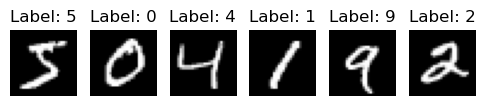

In [3]:
n = 6
fig, axes = plt.subplots(1, n, figsize=(n, 1))
for i in range(n):
    img, label = train_data[i]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")
plt.show()

In [4]:
import torch.nn as nn
import torch.nn.functional as F


class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2
        )
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Tanh with Relu
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
from torch.utils.data import DataLoader, random_split

train_set, val_set = random_split(train_data, [50000, 10000])

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_data)}")

Train: 50000, Val: 10000, Test: 60000


In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = LeNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cpu


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # Clear old gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        # Compute fresh gradients
        loss.backward()
        # Update parameters using those gradients
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

In [9]:
num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
    )

Epoch  1/10 | Train Loss: 0.4078 Acc: 0.8727 | Val Loss: 0.1612 Acc: 0.9500
Epoch  2/10 | Train Loss: 0.1258 Acc: 0.9617 | Val Loss: 0.0998 Acc: 0.9705
Epoch  3/10 | Train Loss: 0.0856 Acc: 0.9734 | Val Loss: 0.0901 Acc: 0.9733
Epoch  4/10 | Train Loss: 0.0654 Acc: 0.9800 | Val Loss: 0.0736 Acc: 0.9775
Epoch  5/10 | Train Loss: 0.0546 Acc: 0.9826 | Val Loss: 0.0688 Acc: 0.9794
Epoch  6/10 | Train Loss: 0.0450 Acc: 0.9854 | Val Loss: 0.0641 Acc: 0.9819
Epoch  7/10 | Train Loss: 0.0376 Acc: 0.9877 | Val Loss: 0.0500 Acc: 0.9854
Epoch  8/10 | Train Loss: 0.0334 Acc: 0.9895 | Val Loss: 0.0536 Acc: 0.9855
Epoch  9/10 | Train Loss: 0.0276 Acc: 0.9910 | Val Loss: 0.0537 Acc: 0.9853
Epoch 10/10 | Train Loss: 0.0254 Acc: 0.9917 | Val Loss: 0.0590 Acc: 0.9852


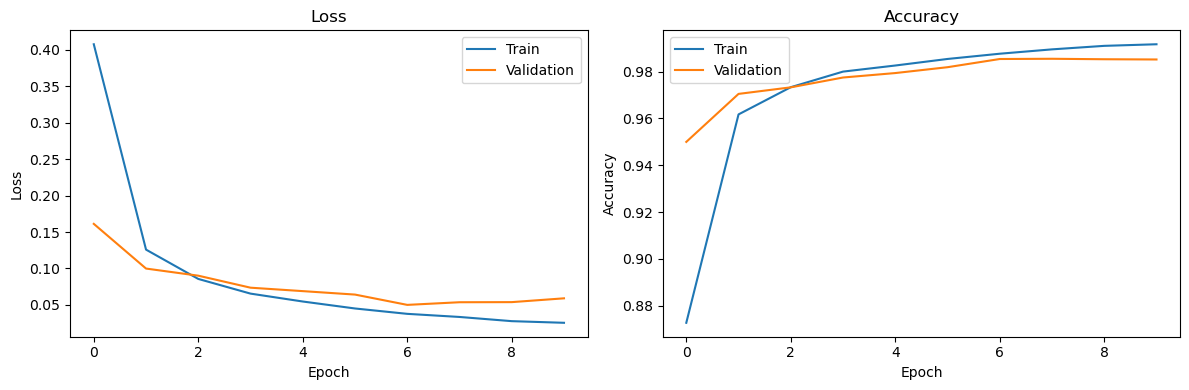

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train")
ax1.plot(val_losses, label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(train_accs, label="Train")
ax2.plot(val_accs, label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0628 | Test Accuracy: 0.9826
